# 17. What is the average number of breaks of serve per match? 

### It imports three libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### The score_ready quality gate is applied

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")
ev_ok = event.loc[event["score_ready"]].copy()
print(f"Matches passing quality gate: {len(ev_ok)} / {len(event)}")

Matches passing quality gate: 14413 / 16873


#### The PowerInfo file (containing the `break_occurred` column for each game) is read and filtered to include only valid matches
#### then, the number of breaks per match is calculated by grouping by `match_id`

In [3]:
power = pd.read_parquet(f"{IN_DIR}/power.parquet")
power = power.merge(ev_ok[["match_id"]], on="match_id", how="inner")
breaks_per_match = power.groupby("match_id")["break_occurred"].sum()

#### The number of matches, as well as the mean and median break per match, are printed

In [4]:
print("Number of matches:", breaks_per_match.shape[0])
print("Average breaks of serve per match:", round(breaks_per_match.mean(), 2))
print("Median breaks of serve per match:", breaks_per_match.median())

Number of matches: 10261
Average breaks of serve per match: 7.01
Median breaks of serve per match: 6.0


#### The histogram of the break distribution for each match is plotted in olive (#7E8B5A); mean (red) and median (orange) lines are added for comparison

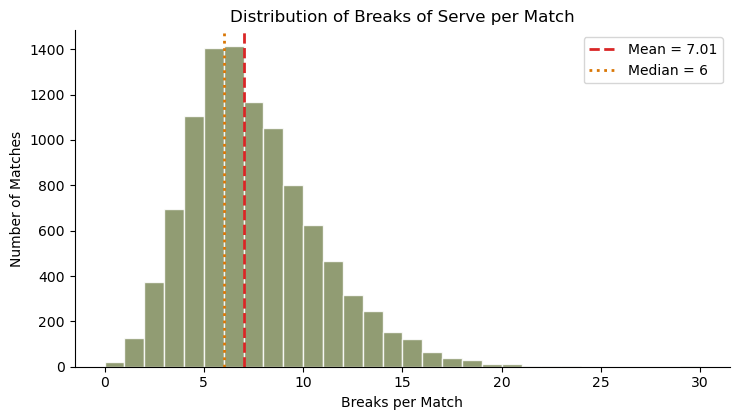

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bins = np.arange(0, breaks_per_match.max() + 2, 1)
ax.hist(breaks_per_match, bins=bins, color="#7E8B5A", alpha=0.85, edgecolor="white")
ax.axvline(breaks_per_match.mean(), color="#d92626", linestyle="--", linewidth=2, label=f"Mean = {breaks_per_match.mean():.2f}")
ax.axvline(breaks_per_match.median(), color="#d97706", linestyle=":", linewidth=2, label=f"Median = {breaks_per_match.median():.0f}")
ax.set_title("Distribution of Breaks of Serve per Match")
ax.set_xlabel("Breaks per Match")
ax.set_ylabel("Number of Matches")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/q17_breaks.png", dpi=170)
plt.show()

The mean number of breaks per match is 7.01, and the median is 6; the narrow gap between the mean and median indicates a relatively symmetrical distribution, albeit with a slight right skew.

This right-hand tail is caused by 1.6% of the data points falling into the outlier range. We chose not to remove them, as they represent genuine occurrences—likely resulting from long matches characterized by poor serving quality or tight competition between two strong returners.

(There were 36 matches recorded with only 1 or 2 games; validation against the home/away team score data confirmed that these were indeed short matches rather than cases of incomplete data, so they were not excluded.)